In [3]:
import datetime
import pandas as pd
from scipy.io import loadmat
from pandas import DataFrame
import keras
!pip install autokeras


In [ ]:
final_data=pd.DataFrame()

In [ ]:
print("Input which battery you need to extract data from. Choose from the following")
print("Battery Number: B0005,B0006,B0007,B0018")
B = input()

Input which battery you need to extract data from. Choose from the following
Battery Number: B0005,B0006,B0007,B0018
B0018


In [ ]:
def to_df(mat_db):
    """Returns one pd.DataFrame per cycle type"""

    # Features common for every cycle
    cycles_cols = ['type', 'ambient_temperature', 'time']

    # Features monitored during the cycle
    features_cols = {
        'charge': ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                'Current_charge', 'Voltage_charge', 'Time'],
        'discharge': ['Voltage_measured', 'Current_measured', 'Temperature_measured',
                    'Current_charge', 'Voltage_charge', 'Time', 'Capacity'],
        'impedance': ['Sense_current', 'Battery_current', 'Current_ratio',
                    'Battery_impedance', 'Rectified_impedance', 'Re', 'Rct']
    }

    # Define one pd.DataFrame per cycle type
    df = {key: pd.DataFrame() for key in features_cols.keys()}

    # Get every cycle
    print(f'Number of cycles: {mat_db[0][0][0].shape[1]}')
    cycles = [[row.flat[0] for row in line] for line in mat_db[0][0][0][0]]

    # Get measures for every cycle
    for cycle_id, cycle_data in enumerate(cycles):
        tmp = pd.DataFrame()

        # Data series for every cycle
        features_x_cycle = cycle_data[-1]

        # Get features for the specific cycle type
        features = features_cols[cycle_data[0]]

        for feature, data in zip(features, features_x_cycle):
            if len(data[0]) > 1:
                # Correct number of records
                tmp[feature] = data[0]
            else:
                # Single value, so assign it to all rows
                tmp[feature] = data[0][0]

        # Add columns common to the cycle measurements
        tmp['id_cycle'] = cycle_id
        for k, col in enumerate(cycles_cols):
            tmp[col] = cycle_data[k]

        # Append cycle data to the right pd.DataFrame
        cycle_type = cycle_data[0]
        df[cycle_type] = df[cycle_type].append(tmp, ignore_index=True)

    return df

In [ ]:
mat_db = loadmat(B+'.mat') [B]
dfs = to_df(mat_db)

dfs["charge"].to_csv("charge_"+B+".csv")
dfs["discharge"].to_csv("discharge_"+B+".csv")
chdf=dfs["charge"]
disdf=dfs["discharge"]

**Current and Voltage during Charging Process-**

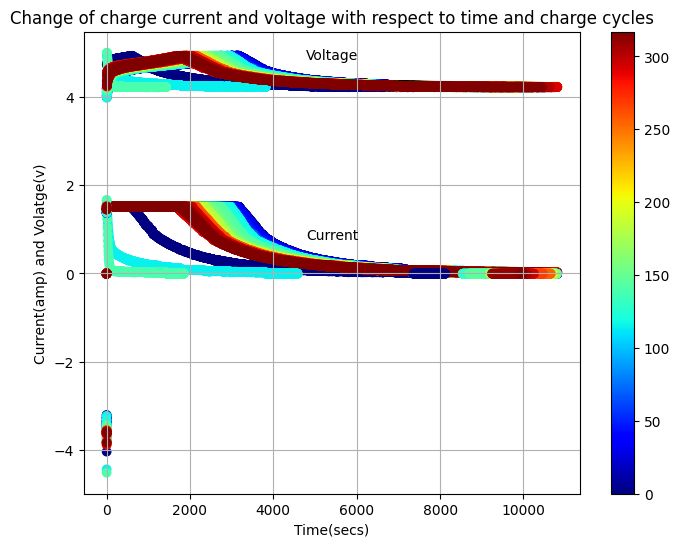

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Plotting the 2D graph
plt.figure(figsize=(8, 6))
plt.scatter(chdf['Time'], chdf['Current_charge'],label='Current', c=chdf['id_cycle'], cmap='jet')  # Color-coded scatter plot
plt.scatter(chdf['Time'], chdf['Voltage_charge'],label='Voltage', c=chdf['id_cycle'], cmap='jet')
plt.xlabel('Time(secs)')
plt.ylabel('Current(amp) and Volatge(v)')
plt.title('Change of charge current and voltage with respect to time and charge cycles')
current_label = 'Current'
voltage_label = 'Voltage'
plt.text(0.5, 0.55, current_label, transform=plt.gca().transAxes, ha='center')
plt.text(0.5, 0.94, voltage_label, transform=plt.gca().transAxes, ha='center')
plt.colorbar()  # Add a colorbar to indicate the third attribute
plt.grid(True)
plt.show()

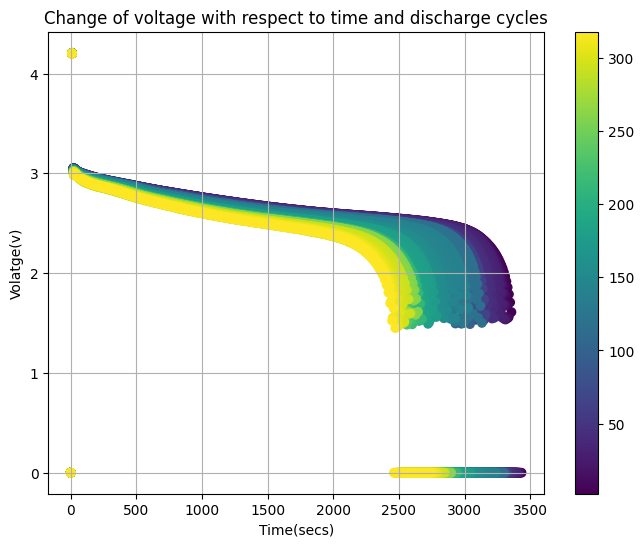

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plotting the 2D graph
plt.figure(figsize=(8, 6))
plt.scatter(disdf['Time'], disdf['Voltage_charge'], c=disdf['id_cycle'], cmap='viridis')  # Color-coded scatter plot
plt.xlabel('Time(secs)')
plt.ylabel('Volatge(v)')
plt.title('Change of voltage with respect to time and discharge cycles')
plt.colorbar()  # Add a colorbar to indicate the third attribute
plt.grid(True)
plt.show()


**Extracting Features of battery (capacity, temperature,IC peak and position of charging/discharging data-**

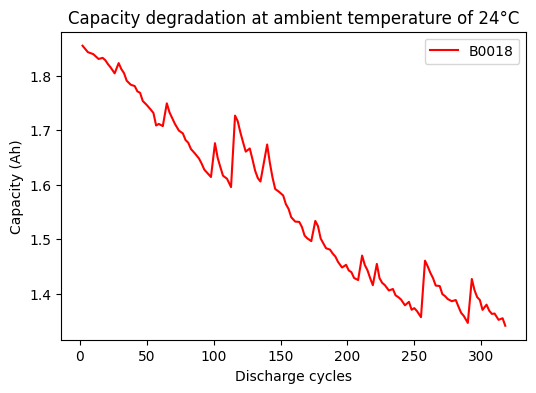

In [ ]:
# load .mat data
import scipy.io
def loadMat(matfile):
    data = scipy.io.loadmat(matfile)
    filename = matfile.split("/")[-1].split(".")[0]
    col = data[filename]
    col = col[0][0][0][0]
    size = col.shape[0]

    data = []
    for i in range(size):
        k = list(col[i][3][0].dtype.fields.keys())
        d1, d2 = {}, {}
        if str(col[i][0][0]) != 'impedance':
            for j in range(len(k)):
                t = col[i][3][0][0][j][0];
                l = [t[m] for m in range(len(t))]
                d2[k[j]] = l
        d1['type'], d1['temp'],  d1['data'] = str(col[i][0][0]), int(col[i][1][0]),  d2
        data.append(d1)

    return data

def getBatteryCapacity(Battery):
  cycle, capacity = [], []
  current, voltage=[],[]
  temperature=[]
  i = 1
  for Bat in Battery:
    if Bat['type'] == 'discharge':
      capacity.append(Bat['data']['Capacity'][0])
      current.append(Bat['data']['Current_load'][1])
      voltage.append(Bat['data']['Voltage_load'][1])
      temperature.append(Bat['data']['Temperature_measured'][1])
      cycle.append(i)
      i += 1
  return [cycle, capacity,current,voltage,temperature]

fig, ax = plt.subplots(1, figsize=(6, 4))
data = loadMat(B + '.mat')
result= getBatteryCapacity(data)
ax.plot(disdf['id_cycle'],disdf['Capacity'], 'r-', label=B)
ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)', title='Capacity degradation at ambient temperature of 24°C')
plt.legend()

In [ ]:
# Store capacity and dischage cycles as HI's also store 2nd value of current_load,voltage_load and Temperature_measured during discharge cycles
# 2nd value because first value often contains noise
HI5 = result[0]  #discharge cycles
HI6=result[1]    #capacity
current = result[2]
voltage=result[3]
temperature=result[4]

In [ ]:
# Extraction of constant current charge cycle data
chcurrent = []
chvoltage=[]
chtime=[]
chbat_cycle=[]
for temp in range(len(chdf['id_cycle'])):
  if(1.4<=chdf['Current_charge'][temp]<=1.6):
    chbat_cycle.append(chdf['id_cycle'][temp])
    chcurrent.append(chdf['Current_measured'][temp])
    chtime.append(chdf['Time'][temp])
    chvoltage.append(chdf['Voltage_measured'][temp])

**Extraction of HI from Charging curve-**

In [ ]:
IC_V=[]
IC_HI=[]
HI1=[]
HI2=[]
IC_HIV={}
ch_cycle=[]
for j in range(len(chcurrent)-1):
  if(chbat_cycle[j]==chbat_cycle[j+1]):
    IC = (chcurrent[j]*(chtime[j+1]-chtime[j]))/(chvoltage[j+1]-chvoltage[j])
    IC_V.append([IC,chvoltage[j],chbat_cycle[j]])
    IC_HI.append(IC)
    IC_HIV[IC]=chvoltage[j]
  else:
    try:
      a=max(IC_HI)
      HI1.append(a)
      HI2.append(IC_HIV[a])
      IC_HI=[]
      IC_HIV={}
      ch_cycle.append(chbat_cycle[j])
    except:
      pass
try:
  a=max(IC_HI)
  HI1.append(a)
  HI2.append(IC_HIV[a])
  ch_cycle.append(chbat_cycle[-1])
  IC_HI=[]
  IC_HIV={}
except:
  pass
print(len(HI1))
print(len(HI2))

134
134


In [ ]:
chcycle=[]
chIC=[]
chVol=[]
for i,j,k in IC_V:
  chcycle.append(k)
  chIC.append(i)
  chVol.append(j)

In [ ]:
# # uncomment to draw the point scatter IC curve for different Discharge cycles
# import numpy as np
# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 6))
# plt.scatter(chVol,chIC,c=chcycle, cmap='jet')  # Color-coded scatter plot
# plt.ylabel('dQ/dV')
# plt.xlabel('Volatge(v)')
# plt.title('IC curve for different charge cycles')
# plt.colorbar()  # Add a colorbar to indicate the third attribute
# plt.grid(True)
# plt.show()

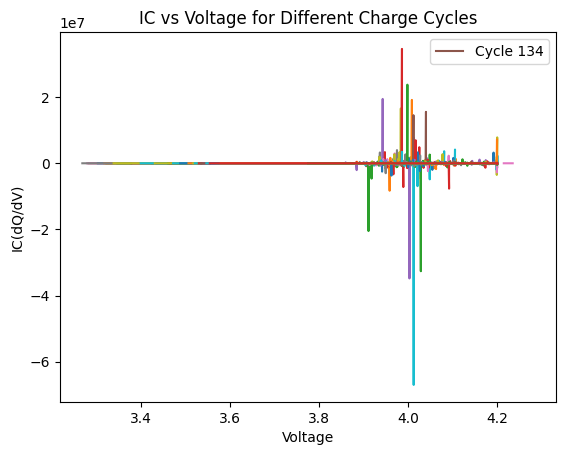

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for cycle in set(chcycle):
    # Filter data for the current cycle
    cycle_IC = [ic for ic, c in zip(chIC, chcycle) if c == cycle]
    cycle_voltage = [v for v, c in zip(chVol, chcycle) if c == cycle]
    # each cycle has diff colour print the label for first,middle,and last cycle only
    if cycle == 1 or cycle == len(set(chcycle))/2 or cycle == len(set(chcycle)):
        ax.plot(cycle_voltage, cycle_IC, label=f'Cycle {cycle}')
    else:
        ax.plot(cycle_voltage, cycle_IC)
ax.set_xlabel('Voltage')
ax.set_ylabel('IC(dQ/dV)')
ax.set_title('IC vs Voltage for Different Charge Cycles')
ax.legend()
plt.show()


**Extraction of HI from Discharging curve-**

In [ ]:
discurrent = []
disvoltage=[]
distime=[]
disbat_cycle=[]
for temp in range(len(disdf['id_cycle'])):
  disbat_cycle.append(disdf['id_cycle'][temp])
  discurrent.append(disdf['Current_measured'][temp])
  distime.append(disdf['Time'][temp])
  disvoltage.append(disdf['Voltage_measured'][temp])

disIC_V=[]
disIC_HI=[]
disIC_HIV={}
HI3=[]
HI4=[]
dis_cycle=[]
for j in range(len(disdf['id_cycle'])-1):
  if(disbat_cycle[j]==disbat_cycle[j+1]):
    disIC = (discurrent[j]*(distime[j+1]-distime[j]))/(disvoltage[j+1]-disvoltage[j])
    disIC_V.append([disIC,disvoltage[j],disbat_cycle[j]])
    disIC_HI.append(disIC)
    disIC_HIV[disIC]=disvoltage[j]

  else:
    a=max(disIC_HI)
    HI3.append(a)
    HI4.append(disIC_HIV[a])
    dis_cycle.append(disbat_cycle[j])
    disIC_HI=[]
    disIC_HIV={}
try:
  a=max(disIC_HI)
  HI3.append(a)
  HI4.append(disIC_HIV[a])
  dis_cycle.append(disbat_cycle[-1])
  IC_HI=[]
  IC_HIV={}
except:
  pass
print(len(HI3))
print(len(HI4))

132
132


In [ ]:
discycle=[]
disIC=[]
disVol=[]
for i,j,k in disIC_V:
  discycle.append(k)
  disIC.append(i)
  disVol.append(j)

In [ ]:
# uncomment to draw the point scatter IC curve for different Discharge cycles
# import numpy as np
# import matplotlib.pyplot as plt
# plt.figure(figsize=(8, 6))
# plt.scatter(disVol,disIC,c=discycle, cmap='jet')  # Color-coded scatter plot
# plt.ylabel('IC(dQ/dV)')
# plt.xlabel('Volatge(v)')
# plt.title('IC curve for different Discharge cycles')
# plt.colorbar()  # Add a colorbar to indicate the third attribute
# plt.grid(True)
# plt.show()

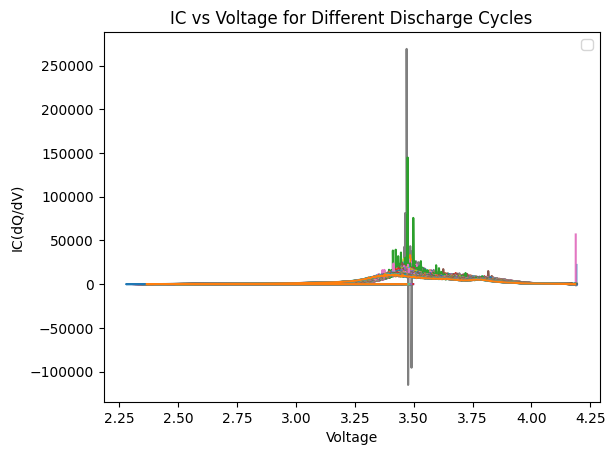

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
for cycle in set(discycle):
    # Filter data for the current cycle
    cycle_IC = [ic for ic, c in zip(disIC, discycle) if c == cycle]
    cycle_voltage = [v for v, c in zip(disVol, discycle) if c == cycle]
    # each cycle has diff colour print the label for first,middle,and last cycle only
    if cycle == 1 or cycle == len(set(discycle))/2 or cycle == len(set(discycle)):
        ax.plot(cycle_voltage, cycle_IC, label=f'Cycle {cycle}')
    else:
        ax.plot(cycle_voltage, cycle_IC)

ax.set_xlabel('Voltage')
ax.set_ylabel('IC(dQ/dV)')
ax.set_title('IC vs Voltage for Different Discharge Cycles')
ax.legend()
plt.show()


In [ ]:
print(len(HI1))
print(len(HI2))
print(len(HI3))
print(len(HI4))
print(len(HI5))
print(len(HI6))
print(len(current))
print(len(voltage))
print(len(temperature))

a=min(len(HI1),len(HI2),len(HI3),len(HI4),len(HI5),len(HI6))
print(a)

134
134
132
132
132
132
132
132
132
132


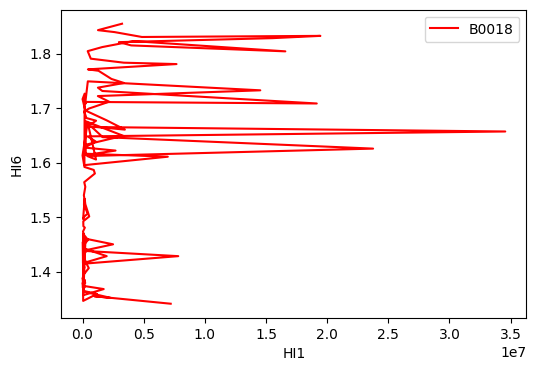

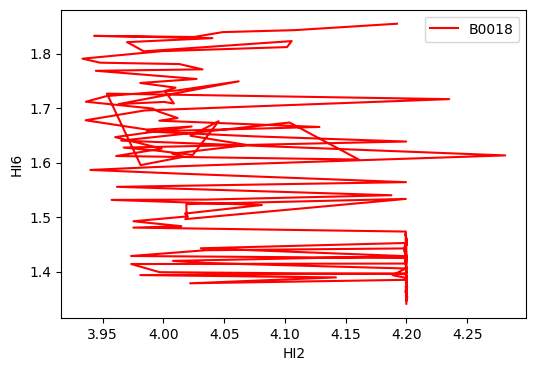

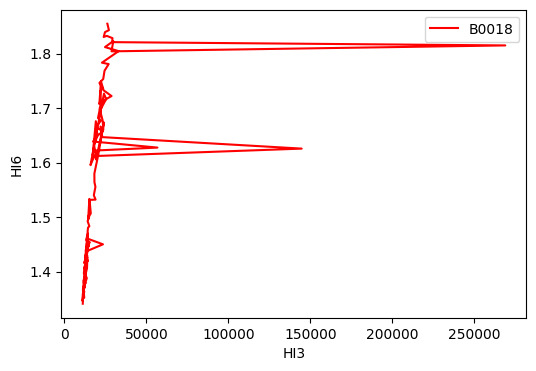

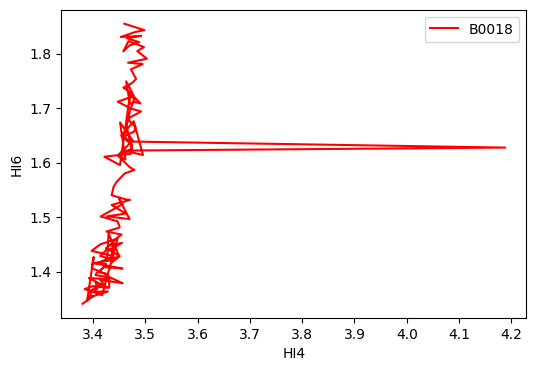

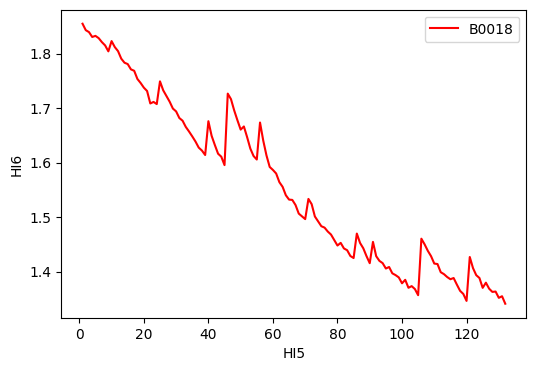

In [ ]:
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI1[:a],HI6, 'r-', label=B)
ax.set(xlabel='HI1', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI2[:a],HI6, 'r-', label=B)
ax.set(xlabel='HI2', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI3[:a],HI6, 'r-', label=B)
ax.set(xlabel='HI3', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI4[:a],HI6, 'r-', label=B)
ax.set(xlabel='HI4', ylabel='HI6')
plt.legend()
fig, ax = plt.subplots(1, figsize=(6, 4))
ax.plot(HI5[:a],HI6, 'r-', label=B)
ax.set(xlabel='HI5', ylabel='HI6')
plt.legend()

In [ ]:
import pandas as pd
import numpy as np
data = {
    'IC_C_H': HI1[:a],
    'IC_C_P': HI2[:a],
    'IC_D_H': HI3[:a],
    'IC_D_P': HI4[:a],
    'Cycles': HI5[:a],
    'capacity': HI6[:a],
    'voltage':voltage[:a],
    'temperature':temperature[:a],
    'current':current[:a]
}

concatenated_df = pd.DataFrame(data)

correlation_matrix = concatenated_df.corr()
# Get the correlation coefficients between 'capacity' and other attributes
capacity_correlation = correlation_matrix['Cycles'].drop('Cycles')

# Sort the correlation coefficients in descending order
sorted_correlation = capacity_correlation.abs().sort_values(ascending=False)

# Print the sorted correlation coefficients
print(sorted_correlation)


capacity       0.969572
IC_C_P         0.638668
voltage        0.583396
IC_D_P         0.409892
temperature    0.384783
IC_C_H         0.324688
IC_D_H         0.323359
current        0.137915
Name: Cycles, dtype: float64


**Writing all HI's in a CSV file and buildung the LSTM Model-**

In [ ]:
import csv
rows = zip(HI5, HI6,HI1,HI2, HI3,HI4)
csv_file = f'{B}_health_index_updated.csv'
# Write the rows to the CSV file
with open(csv_file, 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['cycle', 'capacity', 'IC_C_H', 'IC_C_P','IC_D_H','IC_D_P'])
    # writer.writerow(['cycle', 'capacity', 'current', 'IC_D_H', 'voltage'])  # Write header
    writer.writerows(rows)

print(f"CSV file '{csv_file}' created successfully.")


CSV file 'B0018_health_index_updated.csv' created successfully.


In [10]:
final_data=pd.DataFrame()
three_battries=input()
print("target battery")
target_battery=input()
for i in three_battries.split(","):
  final_data = pd.concat([final_data, pd.read_csv(f'{i}_health_index_updated.csv')], ignore_index=True)

B0018,B0007
target battery
B0006


In [15]:
final_data

,cycle,capacity,IC_C_H,IC_C_P,IC_D_H,IC_D_P
0,1,1.855005,3.230186e+06,4.192140,26228.797508,3.460206
1,2,1.843196,1.260501e+06,4.107696,27180.936279,3.498416
2,3,1.839602,2.626319e+06,4.048678,24787.963978,3.480204
3,4,1.830674,4.856943e+06,4.025268,23973.058106,3.453335
4,5,1.832700,1.945095e+07,3.942964,25887.224011,3.492225
...,...,...,...,...,...,...
295,164,1.406171,1.170657e+06,4.030477,14313.165094,3.435581
296,165,1.406336,5.788491e+05,4.040319,13408.123045,3.423377
297,166,1.400455,4.403711e+05,4.049108,18511.474054,3.446247
298,167,1.421787,9.463530e+06,4.029699,13113.547999,3.452219


In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Load the dataset
dataset = pd.read_csv('B0018_health_index_updated.csv')
target_battery="B0018"
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
train_size = int(0.8* len(dataset))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=60, input_shape=(1, 5)))  # Assuming 50 LSTM units
model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')  #,metrics=['accuracy'])
print(model.summary())


checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")


# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
# print(train_predictions.shape)
# print(test_predictions.shape)
# Inverse transform the predictions
# train_predictions = np.transpose(train_predictions)
# test_predictions = np.transpose(test_predictions)
# train_predictions = scaler.inverse_transform(train_predictions[:,np.newaxis]).flatten()
# test_predictions = scaler.inverse_transform(test_predictions[:,np.newaxis]).flatten()

# Calculate the RUL predictions
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

# Print the RUL predictions
# print(f'Training RUL predictions: {train_rul_predictions}')
# print(f'Testing RUL predictions: {test_rul_predictions}')

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60)                15840     
                                                                 
 dense (Dense)               (None, 64)                3904      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 21857 (85.38 KB)
Trainable params: 21857 (85.38 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None
Epoch 1/200


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: closure mismatch, requested ('self', 'step_function'), but source function had ()
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
102/105 [============================>.] - ETA: 0s - loss: 0.0973

TypeError: ignored

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))

# Build the LSTM model
model = Sequential()
model.add(LSTM(units=60, input_shape=(1, 5)))  # Assuming 50 LSTM units
model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')  #,metrics=['accuracy'])
print(model.summary())

# units = 60,dense_unit=64,dense_unit=32,unit=1-->output layer,epochs=90,batchsize=4
# Train the model
history= model.fit(X_train, y_train, epochs=80, batch_size=4)

# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
# print(train_predictions.shape)
# print(test_predictions.shape)
# Inverse transform the predictions
# train_predictions = np.transpose(train_predictions)
# test_predictions = np.transpose(test_predictions)
# train_predictions = scaler.inverse_transform(train_predictions[:,np.newaxis]).flatten()
# test_predictions = scaler.inverse_transform(test_predictions[:,np.newaxis]).flatten()

# Calculate the RUL predictions
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

# Print the RUL predictions
# print(f'Training RUL predictions: {train_rul_predictions}')
# print(f'Testing RUL predictions: {test_rul_predictions}')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))


# Build the LSTM model
model = Sequential()
model.add(GRU(units=60, input_shape=(1, 5)))  # Assuming 60 GRU units
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1))
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

# units = 60,dense_unit=64,dense_unit=32,unit=1-->output layer,epochs=90,batchsize=4
# Train the model
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
# print(train_predictions.shape)
# print(test_predictions.shape)
# Inverse transform the predictions
# train_predictions = np.transpose(train_predictions)
# test_predictions = np.transpose(test_predictions)
# train_predictions = scaler.inverse_transform(train_predictions[:,np.newaxis]).flatten()
# test_predictions = scaler.inverse_transform(test_predictions[:,np.newaxis]).flatten()

# Calculate the RUL predictions
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

# Print the RUL predictions
# print(f'Training RUL predictions: {train_rul_predictions}')
# print(f'Testing RUL predictions: {test_rul_predictions}')

In [20]:
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Attention
from keras.layers import Input
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense,Attention,LSTM
from keras.callbacks import ModelCheckpoint
from keras.models import load_model

# Load the dataset
dataset = final_data
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
df=pd.read_csv(f'{target_battery}_health_index_updated.csv')
normalized_data = scaler.fit_transform(df)
x_target = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y_target = normalized_data[:, 0]

X_train, X_test = X,x_target
y_train, y_test = y,y_target

# Reshape the input data for LSTM [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))

# Build the LSTM model
attention_input = Input(shape=(1, 5))

# GRU layer
gru_output = LSTM(units=60, return_sequences=True)(attention_input)

# Attention layer
attention = Attention()([gru_output, gru_output])

# Apply attention to GRU output
attended_gru_output = keras.layers.Dot(axes=1)([attention, gru_output])

# Additional layers
dense1 = Dense(units=64, activation='relu')(attended_gru_output)
dense2 = Dense(units=32, activation='relu')(dense1)
output = Dense(units=1)(dense2)

# Create the model
model = Model(inputs=attention_input, outputs=output)

# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')
print(model.summary())

# units = 60,dense_unit=64,dense_unit=32,unit=1-->output layer,epochs=90,batchsize=4
# Train the model
checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Train the model with the callback
history = model.fit(X_train, y_train, epochs=200, batch_size=1, validation_data=(X_test, y_test), callbacks=[checkpoint])

# Load the best model
model = load_model("best_model.h5")
# Evaluate the model
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


# Make predictions
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)
# print(train_predictions.shape)
# print(test_predictions.shape)
# Inverse transform the predictions
# train_predictions = np.transpose(train_predictions)
# test_predictions = np.transpose(test_predictions)
# train_predictions = scaler.inverse_transform(train_predictions[:,np.newaxis]).flatten()
# test_predictions = scaler.inverse_transform(test_predictions[:,np.newaxis]).flatten()

# Calculate the RUL predictions
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]

# Print the RUL predictions
# print(f'Training RUL predictions: {train_rul_predictions}')
# print(f'Testing RUL predictions: {test_rul_predictions}')

Model: "model_7"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_8 (InputLayer)        [(None, 1, 5)]               0         []                            
                                                                                                  
 lstm_7 (LSTM)               (None, 1, 60)                15840     ['input_8[0][0]']             
                                                                                                  
 attention_7 (Attention)     (None, 1, 60)                0         ['lstm_7[0][0]',              
                                                                     'lstm_7[0][0]']              
                                                                                                  
 dot_7 (Dot)                 (None, 60, 60)               0         ['attention_7[0][0]',   

TypeError: ignored

In [ ]:
import autokeras as ak
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import GRU, Dense, Attention
from keras.layers import Input
from keras.models import Model
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import GRU, Dense,Attention,LSTM

# Load the training and validation datasets
# Load the dataset
dataset = pd.read_csv(f'B0018_health_index_updated.csv')
# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(dataset)

# Split the dataset into input (X) and output (y) variables
X = normalized_data[:, 1:9]  # Assuming health index features are in columns 1 to 6
# X = normalized_data[:, 1:5]
y = normalized_data[:, 0]   # number of cycles is in the first column

# Split the dataset into training and testing sets
train_size = int(0.8* len(dataset))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Reshape the input data for LSTM [samples, time steps, features]
# X_train = np.reshape(X_train, (X_train.shape[0],1,  X_train.shape[1]))
# X_test = np.reshape(X_test, (X_test.shape[0],1, X_test.shape[1]))


# Create an AutoKeras regression model
clf = ak.StructuredDataRegressor(
    max_trials=5,
    objective="val_loss"
)

# Train the model on the training dataset
clf.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=200, batch_size=1)


# Make predictions on the validation dataset
train_loss = clf.evaluate(X_train, y_train, verbose=0)
print(f'Training loss: {train_loss}')

test_loss = clf.evaluate(X_test, y_test, verbose=0)
print(f'Testing loss: {test_loss}')


train_predictions = clf.predict(X_train)
test_predictions =clf.predict(X_test)
train_rul_predictions = train_predictions[:, 0]
test_rul_predictions = test_predictions[:, 0]



In [139]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
train_mae = mean_absolute_error(y_train, train_rul_predictions)
test_mae = mean_absolute_error(y_test, test_rul_predictions)

# Calculate RMSE
train_rmse = mean_squared_error(y_train, train_rul_predictions, squared=False)
test_rmse = mean_squared_error(y_test, test_rul_predictions, squared=False)

# Calculate R^2 score
train_r2 = r2_score(y_train, train_rul_predictions)
test_r2 = r2_score(y_test, test_rul_predictions)

# Print the error metrics
# print(f'Training re: {train_re}')
# print(f'Testing re: {test_re}')
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R^2 score: {train_r2}')
print(f'Testing R^2 score: {test_r2}')

with open(f'{target_battery}.txt','w') as f:
  f.write(f'Training loss: {train_loss}\n')
  f.write(f'Testing loss: {test_loss}\n')
  f.write(f'Training MAE: {train_mae}\n')
  f.write(f'Testing MAE: {test_mae}\n')
  f.write(f'Training RMSE: {train_rmse}\n')
  f.write(f'Testing RMSE: {test_rmse}\n')
  f.write(f'Training R^2 score: {train_r2}\n')
  f.write(f'Testing R^2 score: {test_r2}\n')
f.close()


Training MAE: 0.08675659627328249
Testing MAE: 0.07191629468542765
Training RMSE: 0.1072220307674777
Testing RMSE: 0.08360106736251065
Training R^2 score: 0.851813727988811
Testing R^2 score: 0.9171228788037947


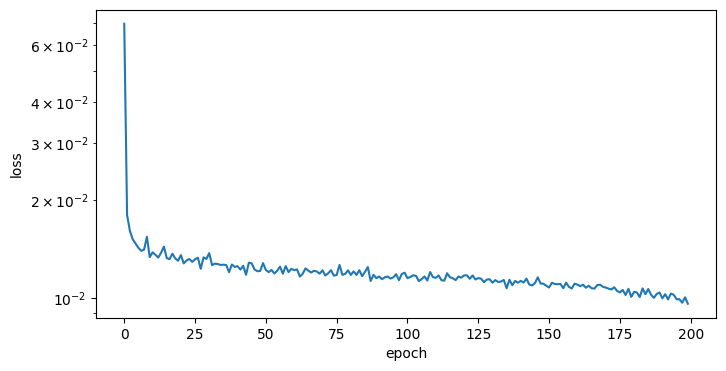

In [140]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8,4)
plt.figure()
plt.ylabel('loss'); plt.xlabel('epoch')
plt.semilogy(history.history['loss'])

In [51]:
# import numpy as np
# max_value = len(HI6)
# initial_values=[]
# predicted_values=[]
# # capcity=[]
# for item in y_test:
#   initial_values.append(int(item*max_value))

# for item in test_rul_predictions:
#   predicted_values.append(int(item*max_value))
# print(initial_values)
# print(predicted_values)
# max_cap=max(list(dataset['capacity']))
# test_capacity=list(dataset['capacity'])[train_size:]
# # for item in test_capacity:
# #   capcity.append(int(item*max_cap))
# # print(capcity)
# # list(dataset['capacity']),max_cap

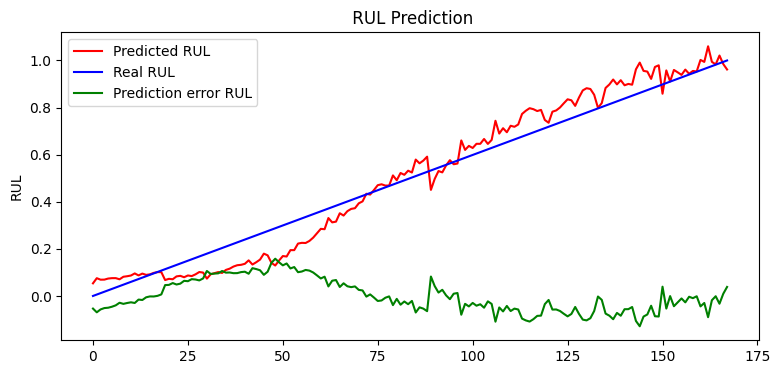

In [47]:
# Denormalizing number of cycle leads to inconsistency, so plot on this value
#Visualization
test_capacity=list(dataset['capacity'])
plt.rcParams["figure.figsize"] = (9,4)
plt.plot(test_rul_predictions,color='red',label='Predicted RUL')
plt.plot(y_test,color='blue',label='Real RUL')
plt.plot(y_test-test_rul_predictions,color='green',label='Prediction error RUL')
plt.title(' RUL Prediction')
# plt.xlabel('capacity')
# plt.ylim(0,2)
plt.ylabel('RUL')
plt.legend()
plt.show()

